# PART 10

Haikal Ali_1103223071_TK46GAB

# Chapter 10 — Row Reduction dan LU Decomposition


## 1. Systems of Equations

Untuk memahami LU decomposition, perlu memahami sistem persamaan, row reduction, dan Gaussian elimination.

Contoh sistem satu persamaan:

$$
2x = 8
$$

Persamaan dapat dimanipulasi selama operasi yang sama diterapkan ke kedua sisi.

Contoh sistem dua persamaan:

$$
x = 4 - y
$$

$$
y = x/2 + 2
$$

Dua persamaan ini harus dipertimbangkan bersama untuk mendapatkan solusi unik. Dengan manipulasi persamaan, solusi yang diperoleh adalah:

$$
x = 4/3, \quad y = 8/3
$$

## 2. Mengubah Persamaan ke Bentuk Matriks

Langkahnya:

1. Letakkan konstanta di sisi kanan.
2. Letakkan variabel dan koefisiennya di sisi kiri dengan urutan yang sama.

Contoh:

$$
x + y = 4
$$

$$
-x/2 + y = 2
$$

Bentuk matriksnya:

$$
\begin{bmatrix}
1 & 1 \\
-1/2 & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
4 \\
2
\end{bmatrix}
$$

Secara umum ditulis sebagai:

$$
Ax = b
$$

## 3. Bekerja dengan Persamaan Matriks

Persamaan matriks dapat dimanipulasi seperti persamaan biasa, tetapi aturan ukuran matriks dan urutan perkalian harus tetap valid.

Karena perkalian matriks tidak komutatif, urutan perkalian sangat penting. Pada persamaan:

$$
AX = B
$$

solusi yang benar adalah:

$$
X = A^{-1}B
$$

bukan:

$$
X = BA^{-1}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import sympy as sym
import time

np.set_printoptions(precision=4, suppress=True)

In [2]:
A = np.random.randn(4,4)
B = np.random.randn(4,4)

# solusi untuk X pada AX = B
X1 = np.linalg.inv(A) @ B
X2 = B @ np.linalg.inv(A)

# residual harus mendekati matriks nol jika solusi benar
res1 = A @ X1 - B
res2 = A @ X2 - B

print('res1:')
print(res1)

print('\nres2:')
print(res2)

res1:
[[ 0. -0. -0.  0.]
 [-0.  0.  0.  0.]
 [-0.  0.  0. -0.]
 [-0.  0.  0.  0.]]

res2:
[[-8.112   4.5275 -1.7119 -1.9178]
 [-7.8617  5.6997 -3.119  -2.0494]
 [ 4.0097 -2.8091  1.5513 -0.3016]
 [ 2.6124 -0.064   0.4636  0.861 ]]


## 4. Row Reduction

Row reduction adalah proses menerapkan operasi scalar multiplication dan addition pada baris matriks.

Tujuan row reduction:

> Mengubah matriks dense menjadi matriks upper-triangular.

Contoh:

$$
\begin{bmatrix}
2 & 3 \\
-2 & 2
\end{bmatrix}
\rightarrow
\begin{bmatrix}
2 & 3 \\
0 & 5
\end{bmatrix}
$$

Matriks upper-triangular hasil row reduction disebut **echelon form**.

## 5. Gaussian Elimination

Gaussian elimination digunakan untuk menyelesaikan sistem persamaan tanpa menghitung inverse secara eksplisit.

Langkahnya:

1. Ubah sistem persamaan menjadi bentuk matriks.
2. Augment matrix koefisien dengan vector konstanta.
3. Lakukan row reduction ke echelon form.
4. Gunakan back substitution untuk menyelesaikan variabel.

Contoh augmented matrix:

$$
\begin{bmatrix}
1 & 1 & 4 \\
-1/2 & 1 & 2
\end{bmatrix}
$$

Setelah row reduction:

$$
\begin{bmatrix}
1 & 1 & 4 \\
0 & 3/2 & 4
\end{bmatrix}
$$

## 6. Gauss-Jordan Elimination dan RREF

Gauss-Jordan elimination melanjutkan Gaussian elimination sampai pivot bernilai 1 dan menjadi satu-satunya angka nonzero di kolomnya.

Hasil akhirnya disebut **Reduced Row Echelon Form (RREF)**.

Untuk contoh sebelumnya, RREF-nya:

$$
\begin{bmatrix}
1 & 0 & 4/3 \\
0 & 1 & 8/3
\end{bmatrix}
$$

Sehingga:

$$
x = 4/3, \quad y = 8/3
$$

In [3]:
M = np.array([
  [1, 1, 4],
  [-1/2, 1, 2]
])

symMat = sym.Matrix(M)
rref_M = symMat.rref()[0]

rref_M

Matrix([
[1, 0, 1.33333333333333],
[0, 1, 2.66666666666667]])

## 7. Matrix Inverse via Gauss-Jordan Elimination

Matrix inverse dapat diperoleh dengan Gauss-Jordan elimination melalui augmented matrix:

$$
\text{rref}([A \mid I]) = [I \mid A^{-1}]
$$

Artinya, jika matriks square full-rank digabung dengan identity matrix, lalu dibuat RREF, sisi kanan hasilnya adalah inverse dari matriks tersebut.

## 8. LU Decomposition

LU decomposition memecah matriks menjadi hasil kali dua matriks triangular:

$$
A = LU
$$

`L` adalah lower-triangular matrix, sedangkan `U` adalah upper-triangular matrix.

Contoh dari materi:

$$
\begin{bmatrix}
2 & 2 & 4 \\
1 & 0 & 3 \\
2 & 1 & 2
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 \\
1/2 & 1 & 0 \\
1 & 1 & 1
\end{bmatrix}
\begin{bmatrix}
2 & 2 & 4 \\
0 & -1 & 1 \\
0 & 0 & -3
\end{bmatrix}
$$

In [4]:
A = np.array([
  [2, 2, 4],
  [1, 0, 3],
  [2, 1, 2]
])

P, L, U = scipy.linalg.lu(A)

print('P:')
print(P)

print('\nL:')
print(L)

print('\nU:')
print(U)

print('\nA - P@L@U:')
print(A - P @ L @ U)

P:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

L:
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [1.  1.  1. ]]

U:
[[ 2.  2.  4.]
 [ 0. -1.  1.]
 [ 0.  0. -3.]]

A - P@L@U:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


## 9. Permutation Matrix

Beberapa matriks membutuhkan row swap agar mudah dibuat upper-triangular. Row swap dapat direpresentasikan menggunakan **permutation matrix**.

Bentuk LU decomposition penuh:

$$
PA = LU
$$

atau:

$$
A = P^T LU
$$

Namun, SciPy menggunakan konvensi:

$$
A = PLU
$$

Permutation matrix bersifat orthogonal, sehingga:

$$
P^{-1} = P^T
$$

## 10. Summary

Poin utama chapter ini:

- Sistem persamaan dapat ditulis sebagai persamaan matriks.
- Dalam persamaan matriks, urutan perkalian harus diperhatikan karena perkalian matriks tidak komutatif.
- Row reduction mengubah matriks dense menjadi upper-triangular matrix.
- Gaussian elimination menyelesaikan sistem persamaan menggunakan row reduction dan back substitution.
- Gauss-Jordan elimination menghasilkan RREF.
- Matrix inverse dapat dihitung dengan RREF dari augmented matrix `[A | I]`.
- LU decomposition memecah matriks menjadi lower-triangular dan upper-triangular matrix.
- Permutation matrix digunakan untuk row swap pada LU decomposition.

# Code Exercises

## Exercise 10-1

Uji waktu LU decomposition untuk 1000 matriks berukuran 100 × 100.

In [5]:
n_iter = 1000
matrix_size = 100

start_time = time.time()

for i in range(n_iter):
  A = np.random.randn(matrix_size, matrix_size)
  P, L, U = scipy.linalg.lu(A)

elapsed_time = time.time() - start_time

print(f'Waktu total untuk {n_iter} LU decomposition ukuran {matrix_size}x{matrix_size}: {elapsed_time:.4f} detik')
print(f'Rata-rata waktu per LU decomposition: {elapsed_time/n_iter:.6f} detik')

Waktu total untuk 1000 LU decomposition ukuran 100x100: 1.7529 detik
Rata-rata waktu per LU decomposition: 0.001753 detik


## Exercise 10-2

Buat matriks 6 × 8 dengan rank 3 menggunakan metode matrix multiplication. Lakukan LU decomposition dan tampilkan rank dari matriks hasilnya.

Rank A: 3
Rank L: 6
Rank U: 3


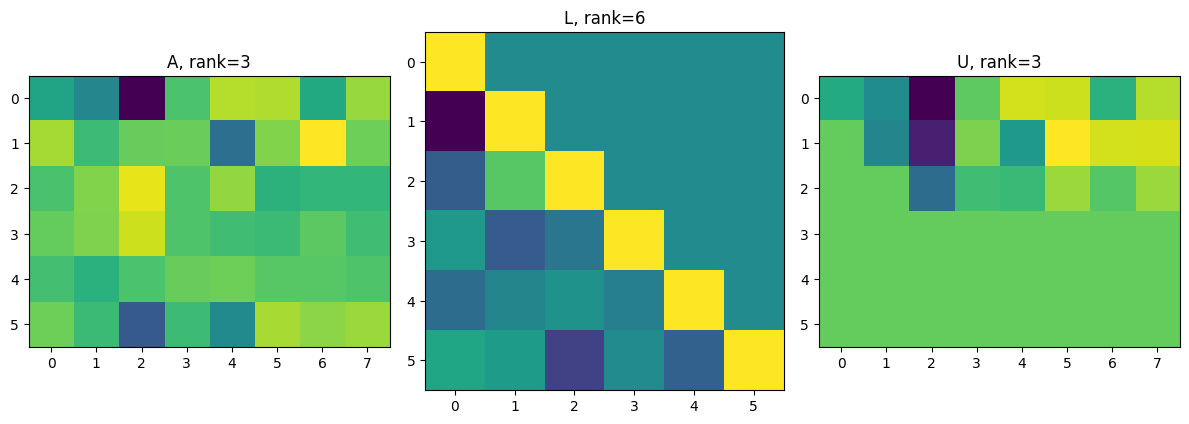

In [6]:
A = np.random.randn(6,3) @ np.random.randn(3,8)

P, L, U = scipy.linalg.lu(A)

print('Rank A:', np.linalg.matrix_rank(A))
print('Rank L:', np.linalg.matrix_rank(L))
print('Rank U:', np.linalg.matrix_rank(U))

fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].imshow(A)
axs[0].set_title(f'A, rank={np.linalg.matrix_rank(A)}')

axs[1].imshow(L)
axs[1].set_title(f'L, rank={np.linalg.matrix_rank(L)}')

axs[2].imshow(U)
axs[2].set_title(f'U, rank={np.linalg.matrix_rank(U)}')

plt.tight_layout()
plt.show()

## Exercise 10-3

Gunakan LU decomposition untuk menghitung determinant. Karena SciPy mengembalikan:

$$
A = PLU
$$

maka:

$$
\det(A) = \det(P)\det(L)\det(U)
$$

Diagonal `L` bernilai 1, sehingga determinant terutama dipengaruhi oleh determinant `P` dan product diagonal `U`.

In [7]:
for i in range(5):
  A = np.random.randn(4,4)
  P, L, U = scipy.linalg.lu(A)

  det_lu_without_P = np.prod(np.diag(U))
  det_lu_with_P = np.linalg.det(P) * np.prod(np.diag(L)) * np.prod(np.diag(U))
  det_numpy = np.linalg.det(A)

  print(f'Percobaan {i+1}')
  print(f'det tanpa P : {det_lu_without_P:.6f}')
  print(f'det dengan P: {det_lu_with_P:.6f}')
  print(f'det NumPy   : {det_numpy:.6f}')
  print()

Percobaan 1
det tanpa P : -0.380191
det dengan P: -0.380191
det NumPy   : -0.380191

Percobaan 2
det tanpa P : -1.933806
det dengan P: -1.933806
det NumPy   : -1.933806

Percobaan 3
det tanpa P : -0.549818
det dengan P: 0.549818
det NumPy   : 0.549818

Percobaan 4
det tanpa P : 2.233813
det dengan P: 2.233813
det NumPy   : 2.233813

Percobaan 5
det tanpa P : -1.279817
det dengan P: -1.279817
det NumPy   : -1.279817



## Exercise 10-4

Implementasikan inverse dengan LU decomposition. Berdasarkan konvensi SciPy:

$$
A = PLU
$$

maka:

$$
A^{-1} = U^{-1}L^{-1}P^T
$$

Kode juga menunjukkan bentuk yang mengikuti konvensi matematika sebelumnya agar terlihat kenapa sanity-check diperlukan.

In [8]:
A = np.random.randn(4,4)
P, L, U = scipy.linalg.lu(A)

I = np.eye(A.shape[0])

# Bentuk ini mengikuti konvensi matematika A = P^T L U
Ainv_wrong = np.linalg.inv(U) @ np.linalg.inv(L) @ P

# Bentuk yang sesuai dengan konvensi SciPy A = P L U
Ainv_scipy = np.linalg.inv(U) @ np.linalg.inv(L) @ P.T

err_wrong = np.linalg.norm(A @ Ainv_wrong - I)
err_scipy = np.linalg.norm(A @ Ainv_scipy - I)

print('Error inverse dengan konvensi matematika sebelumnya:', err_wrong)
print('Error inverse dengan konvensi SciPy:', err_scipy)

print('\nA @ Ainv_scipy:')
print(A @ Ainv_scipy)

Error inverse dengan konvensi matematika sebelumnya: 1.1097578295790953e-15
Error inverse dengan konvensi SciPy: 1.1097578295790953e-15

A @ Ainv_scipy:
[[ 1. -0.  0.  0.]
 [ 0.  1.  0. -0.]
 [ 0.  0.  1. -0.]
 [ 0. -0.  0.  1.]]


## Exercise 10-5

Untuk konvensi SciPy:

$$
A = PLU
$$

maka:

$$
A^T A = U^T L^T P^T P L U
$$

Karena permutation matrix orthogonal:

$$
P^T P = I
$$

maka permutation matrix dapat dihapus:

$$
A^T A = U^T L^T L U
$$

In [9]:
# buat matriks yang permutation matrix-nya bukan identity
while True:
  A = np.random.randn(5,5)
  P, L, U = scipy.linalg.lu(A)
  if not np.allclose(P, np.eye(5)):
    break

left_side = A.T @ A
right_side = U.T @ L.T @ L @ U

print('Apakah P bukan identity matrix?', not np.allclose(P, np.eye(5)))
print('Apakah P.T @ P = I?', np.allclose(P.T @ P, np.eye(5)))
print('Apakah A.T @ A = U.T @ L.T @ L @ U?', np.allclose(left_side, right_side))

print('\nEuclidean distance:')
print(np.linalg.norm(left_side - right_side))

Apakah P bukan identity matrix? True
Apakah P.T @ P = I? True
Apakah A.T @ A = U.T @ L.T @ L @ U? True

Euclidean distance:
2.257605148121872e-15
